In [7]:
import cv2

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("❌ Camera NOT detected on index 0")
else:
    print("✅ Camera opened successfully")

cap.release()


✅ Camera opened successfully


In [2]:
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import ImageFont, ImageDraw, Image
import numpy as np

# Set device to CUDA if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load the pretrained ResNet50 model
num_classes = 31  # Number of classes
model = models.resnet50(weights=None)

# Modify the final layer to output 31 classes (as per your training)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

# Path to your checkpoint file
checkpoint_path = r'C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Model loaded successfully from checkpoint '{checkpoint_path}'")

model.eval()

# Define the transformation to match training preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class_names = [
    'Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh', 'Jeem', 'Kaf', 'Khah',
    'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh', 'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta',
    'Thal', 'Theh', 'Waw', 'Yeh', 'Zah', 'Zain'
]

# Mediapipe Hands
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

# Load a default font for displaying text
fontpath = r'C:\Windows\Fonts\Arial.ttf'
font = ImageFont.truetype(fontpath, 64)

cap = cv2.VideoCapture(0)

last_predicted_class = None

with mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7, min_tracking_confidence=0.5) as hands:
    detect_next = True
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        frame = cv2.flip(frame, 1)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb_frame)

        if detect_next and results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                h, w, c = frame.shape
                x_min, y_min = w, h
                x_max, y_max = 0, 0
                for lm in hand_landmarks.landmark:
                    x, y = int(lm.x * w), int(lm.y * h)
                    x_min, y_min = min(x_min, x), min(y_min, y)
                    x_max, y_max = max(x_max, x), max(y_max, y)

                padding = 100
                x_min, y_min = max(0, x_min - padding), max(0, y_min - padding)
                x_max, y_max = min(w, x_max + padding), min(h, y_max + padding)

                # Debug: Show bounding box coordinates
                print(f"x_min: {x_min}, y_min: {y_min}, x_max: {x_max}, y_max: {y_max}")

                cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                hand_img = frame[y_min:y_max, x_min:x_max]
                hand_img = cv2.cvtColor(hand_img, cv2.COLOR_BGR2RGB)
                hand_pil = transforms.ToPILImage()(hand_img)
                
                input_tensor = preprocess(hand_pil)
                input_tensor = input_tensor.unsqueeze(0).to(device)

                # Debug: Show cropped hand image
                cv2.imshow('Hand Crop', hand_img)

                with torch.no_grad():
                    outputs = model(input_tensor)
                    print(f"Model outputs: {outputs}")
                    _, preds = torch.max(outputs, 1)
                    print(f"Predicted class: {class_names[preds.item()]}")
                    last_predicted_class = class_names[preds.item()]

                detect_next = False
                break

        if last_predicted_class:
            frame_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            draw = ImageDraw.Draw(frame_pil)
            draw.text((50, 50), last_predicted_class, font=font, fill=(0, 255, 0))
            frame = cv2.cvtColor(np.array(frame_pil), cv2.COLOR_RGB2BGR)

        cv2.imshow('Hand Sign Recognition', frame)

        key = cv2.waitKey(1)
        if key == ord('q'):
            break
        elif key == ord(' '):
            detect_next = True

    cap.release()
    cv2.destroyAllWindows()

Using device: cpu
Model loaded successfully from checkpoint 'C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth'
Failed to grab frame


In [6]:
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import ImageFont, ImageDraw, Image
import numpy as np

# Set device to CUDA if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Load the pretrained ResNet50 model
num_classes = 31  # Number of classes
model = models.resnet50(weights=None)

# Modify the final layer to output 31 classes (as per your training)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

# Path to your checkpoint file
checkpoint_path = r'C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Model loaded successfully from checkpoint '{checkpoint_path}'")

model.eval()

# Define the transformation to match training preprocessing
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Updated class names in Arabic
class_names = [
    'ع',  # Ain
    'لا',   # Al
    'أ',  # Alef
    'ب',    # Beh
    'ض',    # Dad
    'د',  # Dal
    'ف',    # Feh
    'غ',    # Ghain
    'ح',    # Hah
    'ه',    # Heh
    'ج',    # Jeem
    'ك',    # Kaf
    'خ',    # Khah
    'ال',   # Laa
    'ل',    # Lam
    'م',    # Meem
    'ن',    # Noon
    'ق',    # Qaf
    'ر',    # Reh
    'ص',    # Sad
    'س',    # Seen
    'ش',    # Sheen
    'ط',    # Tah
    'ت',    # Teh
    'ة',    # Teh_Marbuta
    'ذ',    # Thal
    'ض',    # Theh
    'و',    # Waw
    'ي',    # Yeh
    'ظ',    # Zah
    'ن'     # Zain (duplicate or adjust as necessary)
]

# Mediapipe Hands
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

# Load a default font for displaying text
fontpath = r'C:\Windows\Fonts\Arial.ttf'  # Ensure this font supports Arabic
font = ImageFont.truetype(fontpath, 64)

cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

last_predicted_class = None

with mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7, min_tracking_confidence=0.5) as hands:
    detect_next = True
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        frame = cv2.flip(frame, 1)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb_frame)

        if detect_next and results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                h, w, c = frame.shape
                x_min, y_min = w, h
                x_max, y_max = 0, 0
                for lm in hand_landmarks.landmark:
                    x, y = int(lm.x * w), int(lm.y * h)
                    x_min, y_min = min(x_min, x), min(y_min, y)
                    x_max, y_max = max(x_max, x), max(y_max, y)

                padding = 100
                x_min, y_min = max(0, x_min - padding), max(0, y_min - padding)
                x_max, y_max = min(w, x_max + padding), min(h, y_max + padding)

                # Debug: Show bounding box coordinates
                print(f"x_min: {x_min}, y_min: {y_min}, x_max: {x_max}, y_max: {y_max}")

                cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                hand_img = frame[y_min:y_max, x_min:x_max]
                hand_img = cv2.cvtColor(hand_img, cv2.COLOR_BGR2RGB)
                hand_pil = transforms.ToPILImage()(hand_img)
                
                input_tensor = preprocess(hand_pil)
                input_tensor = input_tensor.unsqueeze(0).to(device)

                # Debug: Show cropped hand image
                cv2.imshow('Hand Crop', hand_img)

                with torch.no_grad():
                    outputs = model(input_tensor)
                    print(f"Model outputs: {outputs}")
                    _, preds = torch.max(outputs, 1)
                    print(f"Predicted class: {class_names[preds.item()]}")
                    last_predicted_class = class_names[preds.item()]

                detect_next = False
                break

        if last_predicted_class:
            frame_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            draw = ImageDraw.Draw(frame_pil)
            draw.text((50, 50), last_predicted_class, font=font, fill=(0, 255, 0))
            frame = cv2.cvtColor(np.array(frame_pil), cv2.COLOR_RGB2BGR)

        cv2.imshow('Hand Sign Recognition', frame)

        key = cv2.waitKey(2)
        if key == ord('q'):
            break
        #elif key == ord(' '):
            #detect_next = True

    cap.release()
    cv2.destroyAllWindows()


Using device: cpu
Model loaded successfully from checkpoint 'C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth'
Failed to grab frame


In [2]:
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import ImageFont, ImageDraw, Image
import numpy as np
import time


# ============================================
#               CONFIG & CONSTANTS
# ============================================
CHECKPOINT_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth"
FONT_PATH = r"C:\Windows\Fonts\Arial.ttf"
CAM_INDEX = 1
BBOX_PADDING = 60
NUM_CLASSES = 31
CLASS_NAMES = [
    'Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh',
    'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh',
    'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh',
    'Waw', 'Yeh', 'Zah', 'Zain'
]


# ============================================
#               MODEL LOADING
# ============================================
def load_model(checkpoint_path, num_classes):
    print("Loading model...")

    model = models.resnet50(weights=None)  # will be replaced by checkpoint
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    print("Model loaded successfully.")
    return model, device


# ============================================
#           PREPROCESSING PIPELINE
# ============================================
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


# ============================================
#           PREDICTION FUNCTION
# ============================================
def predict_hand(model, device, img_rgb):
    """Run the model on a cropped RGB hand image."""
    hand_pil = Image.fromarray(img_rgb)
    tensor = preprocess(hand_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred_idx = torch.max(probs, 1)

    label = CLASS_NAMES[pred_idx.item()]
    confidence = conf.item()
    return label, confidence


# ============================================
#             CAMERA INITIALIZATION
# ============================================
def init_camera(index=0):
    cap = cv2.VideoCapture(index, cv2.CAP_DSHOW)
    time.sleep(1)

    if not cap.isOpened():
        print(f"❌ ERROR: Camera at index {index} not available.")
        exit()

    # Warm-up frames
    for _ in range(10):
        ret, _ = cap.read()
        if ret:
            print("Camera ready.")
            return cap

    print("❌ Camera opened but cannot read frames.")
    exit()


# ============================================
#           DRAW TEXT ON FRAME
# ============================================
def draw_text(frame, text, font):
    frame_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(frame_pil)
    draw.text((50, 50), text, font=font, fill=(0, 255, 0))
    return cv2.cvtColor(np.array(frame_pil), cv2.COLOR_RGB2BGR)


# ============================================
#                   MAIN APP
# ============================================
def main():
    # Load model & font
    model, device = load_model(CHECKPOINT_PATH, NUM_CLASSES)
    font = ImageFont.truetype(FONT_PATH, 64)

    # Initialize camera
    cap = init_camera(CAM_INDEX)

    # Mediapipe hands
    mp_hands = mp.solutions.hands
    detect_next = True
    last_label = None
    last_conf = None

    with mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        min_detection_confidence=0.7,
        min_tracking_confidence=0.5
    ) as hands:

        while True:
            ret, frame = cap.read()
            if not ret:
                print("⚠️ Warning: Failed to grab frame.")
                continue

            frame = cv2.flip(frame, 1)
            h, w, _ = frame.shape

            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(rgb_frame)

            # -----------------------------------------------
            #       HAND DETECTION & CROP
            # -----------------------------------------------
            if detect_next and results.multi_hand_landmarks:
                lm = results.multi_hand_landmarks[0]

                xs = [int(p.x * w) for p in lm.landmark]
                ys = [int(p.y * h) for p in lm.landmark]

                x_min = max(0, min(xs) - BBOX_PADDING)
                x_max = min(w, max(xs) + BBOX_PADDING)
                y_min = max(0, min(ys) - BBOX_PADDING)
                y_max = min(h, max(ys) + BBOX_PADDING)

                if x_max > x_min and y_max > y_min:
                    crop = frame[y_min:y_max, x_min:x_max]

                    if crop.size != 0:
                        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
                        label, conf = predict_hand(model, device, crop_rgb)
                        print(f"Prediction: {label} | Confidence: {conf:.2f}")

                        last_label = label
                        last_conf = conf

                        detect_next = False

            # -----------------------------------------------
            #        DRAW PREDICTION ON FRAME
            # -----------------------------------------------
            if last_label:
                text = f"{last_label} ({last_conf*100:.1f}%)"
                frame = draw_text(frame, text, font)

            cv2.imshow("Hand Sign Recognition", frame)

            # -----------------------------------------------
            #                KEYBOARD INPUT
            # -----------------------------------------------
            key = cv2.waitKey(1)

            if key == ord('q'):
                break

            if key == ord(' '):
                detect_next = True
                last_label = None
                last_conf = None

    cap.release()
    cv2.destroyAllWindows()


# ============================================
#               RUN THE APP
# ============================================
if __name__ == "__main__":
    main()



Loading model...
Model loaded successfully.
Camera ready.


C:\Users\baraj\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Prediction: Beh | Confidence: 0.39
Prediction: Khah | Confidence: 0.36
Prediction: Teh | Confidence: 0.19
Prediction: Beh | Confidence: 0.43
Prediction: Alef | Confidence: 0.69
Prediction: Jeem | Confidence: 0.23
Prediction: Jeem | Confidence: 0.66
Prediction: Jeem | Confidence: 0.85
Prediction: Noon | Confidence: 0.46
Prediction: Khah | Confidence: 0.53
Prediction: Hah | Confidence: 0.42
Prediction: Jeem | Confidence: 0.76
Prediction: Jeem | Confidence: 0.42
Prediction: Jeem | Confidence: 0.69
Prediction: Jeem | Confidence: 0.11
Prediction: Jeem | Confidence: 0.33
Prediction: Jeem | Confidence: 0.32
Prediction: Alef | Confidence: 0.64
Prediction: Alef | Confidence: 0.86
Prediction: Ghain | Confidence: 0.52
Prediction: Alef | Confidence: 0.90
Prediction: Alef | Confidence: 0.35
Prediction: Alef | Confidence: 0.35
Prediction: Alef | Confidence: 0.74
Prediction: Alef | Confidence: 0.51
Prediction: Alef | Confidence: 0.26
Prediction: Alef | Confidence: 0.20
Prediction: Alef | Confidence: 

In [6]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================
# CONFIGURATION
# =====================================
CSV_PATH = r"C:\Users\baraj\Downloads\Mysora App\ArSL_Data_Labels.csv"  # UPDATE NAME
IMAGE_FOLDER = r"C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset"
CHECKPOINT_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth"

# Model class order (must match EXACTLY training)
CLASS_NAMES = [
    'Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh',
    'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh',
    'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh',
    'Waw', 'Yeh', 'Zah', 'Zain'
]

# lowercase → uppercase mapping
label_map = {cls.lower(): cls for cls in CLASS_NAMES}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# =====================================
# CUSTOM DATASET FROM CSV
# =====================================
class ArabicSignsDataset(Dataset):
    def __init__(self, csv_path, img_folder, transform=None):
        self.data = pd.read_csv(csv_path)
        self.img_folder = img_folder
        self.transform = transform

        # Map CSV label → model label → class index
        self.data['mapped_label'] = self.data['Class'].str.lower().map(label_map)
        self.data['label_idx'] = self.data['mapped_label'].apply(CLASS_NAMES.index)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        img_path = os.path.join(self.img_folder, row['File_Name'])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = row['label_idx']
        return image, label


# =====================================
# MODEL LOADING
# =====================================
def load_model():
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(CLASS_NAMES))
    model = model.to(device)

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model


# =====================================
# PREPROCESS & DATALOADER
# =====================================
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = ArabicSignsDataset(CSV_PATH, IMAGE_FOLDER, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)


# =====================================
# EVALUATION LOOP
# =====================================
def evaluate(model, loader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)


model = load_model()
preds, labels = evaluate(model, loader)


# =====================================
# METRICS
# =====================================
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(labels, preds, target_names=CLASS_NAMES))

accuracy = accuracy_score(labels, preds)
print(f"\nOverall Accuracy: {accuracy * 100:.2f}%")


# =====================================
# CONFUSION MATRIX
# =====================================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)

print("\nSaved confusion_matrix.png")


ValueError: nan is not in list

In [9]:
import pandas as pd


df = pd.read_csv(CSV_PATH)

print("Unique labels from CSV:")
print(df['Class'].unique())

# Check which labels are NOT recognized
lower_csv_labels = set(df['Class'].str.lower().unique())
lower_model_labels = set([c.lower() for c in [
    'Ain','Al','Alef','Beh','Dad','Dal','Feh','Ghain','Hah','Heh',
    'Jeem','Kaf','Khah','Laa','Lam','Meem','Noon','Qaf','Reh',
    'Sad','Seen','Sheen','Tah','Teh','Teh_Marbuta','Thal','Theh',
    'Waw','Yeh','Zah','Zain'
]])

print("\nLabels NOT recognized:")
print(lower_csv_labels - lower_model_labels)


Unique labels from CSV:
['ain' 'al' 'aleff' 'bb' 'dal' 'dha' 'dhad' 'fa' 'gaaf' 'ghain' 'ha' 'haa'
 'jeem' 'kaaf' 'khaa' 'la' 'laam' 'meem' 'nun' 'ra' 'saad' 'seen' 'sheen'
 'ta' 'taa' 'thaa' 'thal' 'toot' 'waw' 'ya' 'yaa' 'zay']

Labels NOT recognized:
{'saad', 'fa', 'thaa', 'ra', 'ha', 'haa', 'ta', 'toot', 'zay', 'laam', 'bb', 'nun', 'la', 'aleff', 'kaaf', 'dha', 'khaa', 'gaaf', 'ya', 'taa', 'yaa', 'dhad'}


In [13]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================
# CONFIG
# =====================================
CSV_PATH = r"C:\Users\baraj\Downloads\Mysora App\ArSL_Data_Labels.csv"  # UPDATE NAME
IMAGE_FOLDER = r"C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset"
CHECKPOINT_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth"

CLASS_NAMES = [
    'Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh',
    'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh',
    'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh',
    'Waw', 'Yeh', 'Zah', 'Zain'
]

label_map = {
    "ain": "Ain",
    "al": "Al",
    "aleff": "Alef",
    "bb": "Beh",
    "dal": "Dal",
    "dha": "Zah",
    "dhad": "Dad",
    "fa": "Feh",
    "gaaf": "Qaf",
    "ghain": "Ghain",
    "ha": "Hah",
    "haa": "Heh",
    "jeem": "Jeem",
    "kaaf": "Kaf",
    "khaa": "Khah",
    "la": "Laa",
    "laam": "Lam",
    "meem": "Meem",
    "nun": "Noon",
    "ra": "Reh",
    "saad": "Sad",
    "seen": "Seen",
    "sheen": "Sheen",
    "ta": "Tah",
    "taa": "Teh",
    "thaa": "Theh",
    "thal": "Thal",
    "toot": "Teh_Marbuta",
    "waw": "Waw",
    "ya": "Yeh",
    "yaa": "Yeh",
    "zay": "Zain"
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =====================================
# CUSTOM DATASET (CSV + Subfolders)
# =====================================
class ArabicSignsDataset(Dataset):
    def __init__(self, csv_path, img_folder, transform=None):
        self.data = pd.read_csv(csv_path)
        self.img_folder = img_folder
        self.transform = transform

        # Normalize and map labels
        self.data['mapped_label'] = (
            self.data['Class'].astype(str).str.strip().str.lower().map(label_map)
        )

        # Remove unknown labels
        self.data = self.data.dropna(subset=['mapped_label'])

        # Convert to class index
        self.data['label_idx'] = self.data['mapped_label'].apply(CLASS_NAMES.index)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        class_folder = row['mapped_label']    # e.g., "Laa"
        filename = row['File_Name']          # e.g., "Laa_8.jpg"

        img_path = os.path.join(self.img_folder, class_folder, filename)

        if not os.path.exists(img_path):
            print("Missing file:", img_path)
            return None

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, row['label_idx']


# =====================================
# LOAD MODEL
# =====================================
def load_model():
    model = models.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
    model = model.to(device)

    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model


# =====================================
# DATASET + DATALOADER
# =====================================
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = ArabicSignsDataset(CSV_PATH, IMAGE_FOLDER, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)


# =====================================
# EVALUATION LOOP
# =====================================
def evaluate(model, loader):
    preds, labels = [], []

    with torch.no_grad():
        for batch in loader:
            if batch is None:
                continue

            images, y = batch
            images = images.to(device)
            y = y.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            preds.extend(pred.cpu().numpy())
            labels.extend(y.cpu().numpy())

    return np.array(preds), np.array(labels)


model = load_model()
preds, labels = evaluate(model, loader)


# =====================================
# METRICS
# =====================================
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(labels, preds, target_names=CLASS_NAMES))

acc = accuracy_score(labels, preds)
print(f"\nOverall Accuracy: {acc*100:.2f}%")


# =====================================
# CONFUSION MATRIX
# =====================================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(20, 16))
sns.heatmap(cm, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)

print("\nSaved: confusion_matrix.png")


Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (10).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (100).jpg
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1000).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1001).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1002).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1003).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1004).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1005).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1006).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Ain\AIN (1007).JPG
Missing file: C:\Users\baraj\Downloads\Mysora App\RGB ArSL d

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'NoneType'>

In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# CONFIG
# ================================
DATASET_PATH = r"C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset"
CHECKPOINT_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth"

CLASS_NAMES = [
    'Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh',
    'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh',
    'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh',
    'Waw', 'Yeh', 'Zah', 'Zain'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================================
# PREPROCESSING
# ================================
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ================================
# LOAD DATASET USING FOLDER STRUCTURE
# ================================
dataset = datasets.ImageFolder(DATASET_PATH, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

print("Folders detected (must match model):")
print(dataset.classes)

# ================================
# LOAD MODEL
# ================================
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
model = model.to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# ================================
# EVALUATION LOOP
# ================================
preds, labels = [], []

with torch.no_grad():
    for images, lbls in loader:
        images = images.to(device)
        lbls = lbls.to(device)

        outputs = model(images)
        _, pred = torch.max(outputs, 1)

        preds.extend(pred.cpu().numpy())
        labels.extend(lbls.cpu().numpy())

preds = np.array(preds)
labels = np.array(labels)

# ================================
# METRICS
# ================================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(labels, preds, target_names=CLASS_NAMES))

acc = accuracy_score(labels, preds)
print("\nFinal Accuracy:", acc)

# ================================
# CONFUSION MATRIX
# ================================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(18, 16))
sns.heatmap(cm, cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)

print("\nSaved confusion_matrix.png")


Folders detected (must match model):
['Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh', 'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh', 'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh', 'Waw', 'Yeh', 'Zah', 'Zain']


OSError: image file is truncated (7 bytes not processed)

Folders detected:
['Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh', 'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh', 'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh', 'Waw', 'Yeh', 'Zah', 'Zain']
⚠️ Corrupted image skipped: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Yeh\Yeh_61.jpg

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         Ain       0.97      0.94      0.95       244
          Al       0.97      0.94      0.95       276
        Alef       0.96      0.98      0.97       287
         Beh       0.85      0.92      0.88       307
         Dad       0.94      0.96      0.95       266
         Dal       0.83      0.88      0.86       235
         Feh       0.89      0.77      0.83       255
       Ghain       0.94      0.95      0.95       230
         Hah       0.90      0.89      0.89       246
         Heh       0.90      0.96      0.93       253
        Jeem       0.9

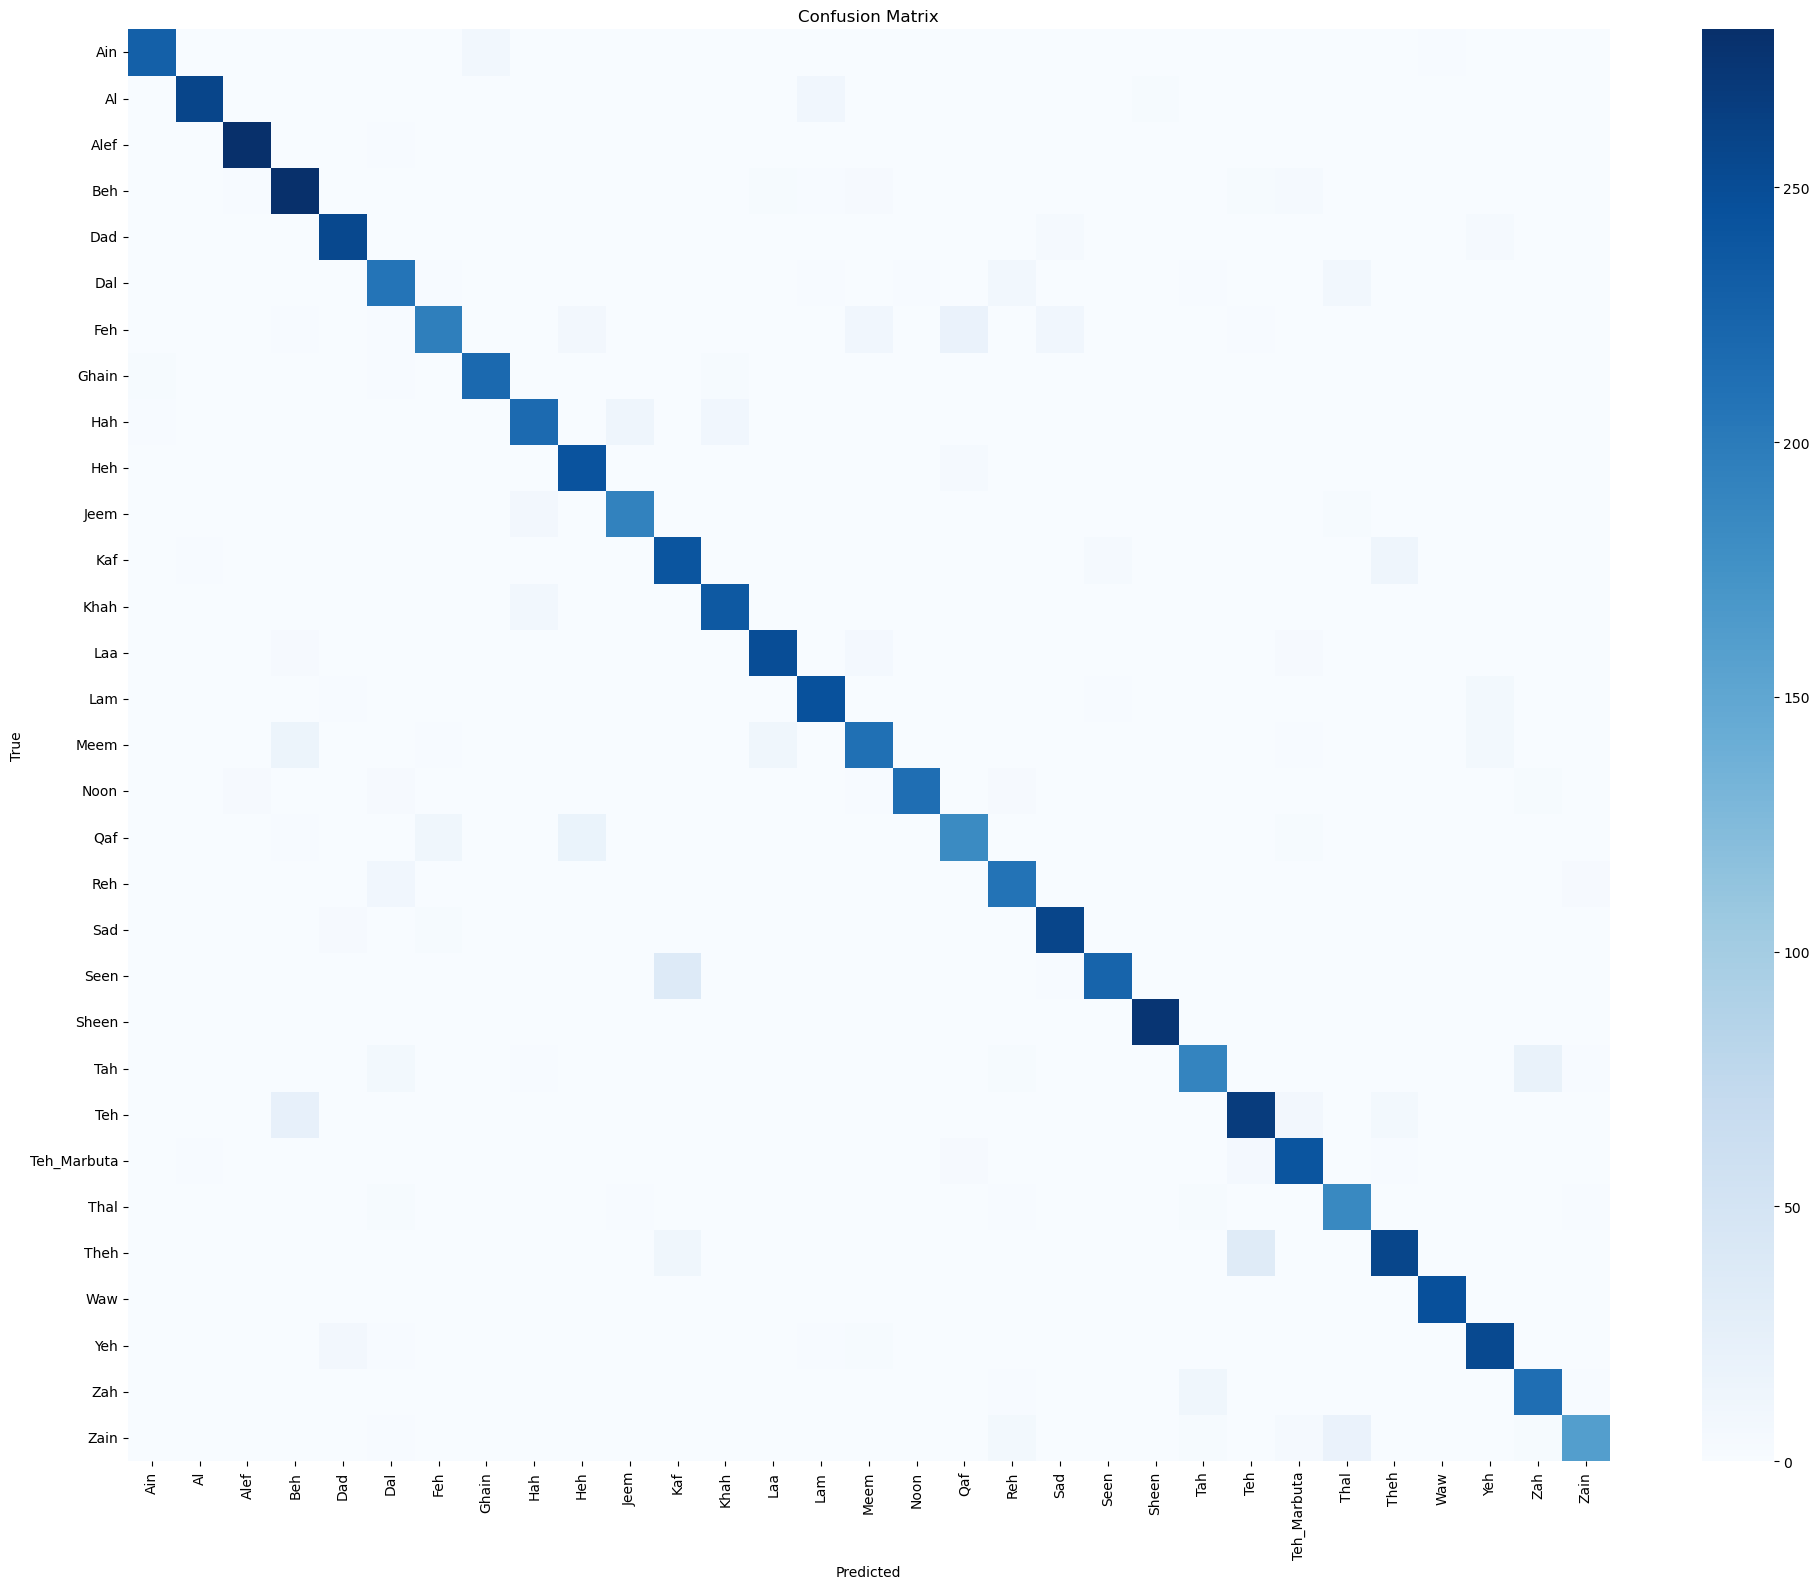

In [4]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image, UnidentifiedImageError
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os

# ================================
# CONFIG
# ================================
DATASET_PATH = r"C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset"
CHECKPOINT_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth"

CLASS_NAMES = [
    'Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh',
    'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh',
    'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh',
    'Waw', 'Yeh', 'Zah', 'Zain'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ================================
# SAFER IMAGE LOADER
# ================================
def safe_loader(path):
    try:
        img = Image.open(path)
        return img.convert("RGB")
    except (OSError, UnidentifiedImageError):
        print(f"⚠️ Corrupted image skipped: {path}")
        return None


# Monkey-patch torchvision's default loader
datasets.folder.default_loader = safe_loader


# ================================
# PREPROCESSING
# ================================
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ================================
# LOAD DATASET
# ================================
dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

print("Folders detected:")
print(dataset.classes)


# ================================
# LOAD MODEL
# ================================
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))
model = model.to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


# ================================
# EVALUATION LOOP
# ================================
preds, labels = [], []

with torch.no_grad():
    for paths, targets in loader.dataset.samples:
        img = safe_loader(paths)
        if img is None:
            continue

        img = transform(img).unsqueeze(0).to(device)
        target_idx = targets

        output = model(img)
        _, pred = torch.max(output, 1)

        preds.append(pred.item())
        labels.append(target_idx)

preds = np.array(preds)
labels = np.array(labels)


# ================================
# METRICS
# ================================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(labels, preds, target_names=CLASS_NAMES))

acc = accuracy_score(labels, preds)
print(f"\nFinal Accuracy: {acc*100:.2f}%")

# ================================
# CONFUSION MATRIX
# ================================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(20, 16))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=300)

print("\nSaved confusion_matrix.png")


In [1]:
import torchvision.datasets.folder as folder
from PIL import Image, UnidentifiedImageError

# ==========================================
# GLOBAL SAFE LOADER (prevents PIL crashes)
# ==========================================
def safe_loader(path):
    try:
        img = Image.open(path)
        return img.convert("RGB")
    except Exception:
        print(f"⚠️ Corrupted image skipped: {path}")
        return None

# Override ALL possible torchvision loaders
folder.default_loader = safe_loader
folder.pil_loader = safe_loader
folder.accimage_loader = safe_loader


In [3]:
train_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(DATASET_PATH, transform=val_transform)


NameError: name 'datasets' is not defined

In [4]:
# ==========================================
# FORCE datasets to use safe_loader
# ==========================================
train_dataset.loader = safe_loader
val_dataset.loader = safe_loader

# ==========================================
# REMOVE CORRUPTED IMAGES FROM DATASET LIST
# ==========================================
clean_train = []
for path, label in train_dataset.samples:
    try:
        img = Image.open(path)
        img.verify()  # detect truncation
        clean_train.append((path, label))
    except Exception:
        print(f"🚨 Removed corrupted TRAIN image: {path}")

train_dataset.samples = clean_train


clean_val = []
for path, label in val_dataset.samples:
    try:
        img = Image.open(path)
        img.verify()
        clean_val.append((path, label))
    except Exception:
        print(f"🚨 Removed corrupted VAL image: {path}")

val_dataset.samples = clean_val


NameError: name 'train_dataset' is not defined

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import models, transforms, datasets
import torchvision.datasets.folder as folder
from sklearn.metrics import f1_score
from PIL import Image, UnidentifiedImageError
import numpy as np
import os

# =============================================
# CONFIG
# =============================================
DATASET_PATH = r"C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset"
CHECKPOINT_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth"

NUM_CLASSES = 31
BATCH_SIZE = 32
EPOCHS = 8
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ==========================================================
# (A) GLOBAL SAFE LOADER — Prevents crash on corrupted images
# ==========================================================
def safe_loader(path):
    try:
        img = Image.open(path)
        return img.convert("RGB")
    except Exception:
        print(f"⚠️ Corrupted image skipped: {path}")
        return None

# Override all torchvision loaders
folder.default_loader = safe_loader
folder.pil_loader = safe_loader
folder.accimage_loader = safe_loader


# =============================================
# DATA AUGMENTATION — strong for tricky letters
# =============================================
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
    ], p=0.5),

    transforms.RandomApply([
        transforms.RandomAffine(degrees=25, translate=(0.1, 0.1), scale=(0.85, 1.15))
    ], p=0.5),

    transforms.RandomApply([
        transforms.RandomPerspective(distortion_scale=0.4)
    ], p=0.3),

    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.3),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# =============================================
# (B) LOAD DATASETS
# =============================================
train_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(DATASET_PATH, transform=val_transform)


# =============================================
# (C) FORCE BOTH DATASETS TO USE safe_loader
# =============================================
train_dataset.loader = safe_loader
val_dataset.loader = safe_loader

# =============================================
# Remove corrupted images from dataset samples
# =============================================
clean_train = []
for path, label in train_dataset.samples:
    try:
        img = Image.open(path)
        img.verify()
        clean_train.append((path, label))
    except Exception:
        print(f"🚨 Removed corrupted TRAIN image: {path}")

train_dataset.samples = clean_train

clean_val = []
for path, label in val_dataset.samples:
    try:
        img = Image.open(path)
        img.verify()
        clean_val.append((path, label))
    except Exception:
        print(f"🚨 Removed corrupted VAL image: {path}")

val_dataset.samples = clean_val

print("Final TRAIN image count:", len(train_dataset.samples))
print("Final VAL image count:", len(val_dataset.samples))


# =============================================
# CLASS-BALANCED SAMPLER (fix class imbalance)
# =============================================
targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets)
print("Class counts:", class_counts)

weights = 1.0 / class_counts
sample_weights = np.array([weights[t] for t in targets])
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))


# =============================================
# DATA LOADERS
# =============================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)


# =============================================
# MODEL LOADING & FINE-TUNING
# =============================================
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

# Freeze all layers except last block + FC
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                       lr=LR)

criterion = nn.CrossEntropyLoss()


# =============================================
# TRAIN + VALIDATION FUNCTIONS
# =============================================
def train_one_epoch():
    model.train()
    total_loss, correct = 0, 0

    for images, labels in train_loader:
        if images is None:
            continue

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    return total_loss / len(train_loader), correct / len(train_dataset)


def validate():
    model.eval()
    total_loss = 0
    preds_list = []
    labels_list = []

    with torch.no_grad():
        for images, labels in val_loader:
            if images is None:
                continue

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    f1 = f1_score(labels_list, preds_list, average="macro")
    return total_loss / len(val_loader), f1


# =============================================
# TRAINING LOOP — Save best model by F1 score
# =============================================
best_f1 = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_f1 = validate()

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val F1:   {val_f1:.4f}")
    print("----------------------------------------")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_f1": best_f1,
                "epoch": epoch + 1,
            },
            "MysoraBestModel.pth"
        )
        print(f"🔥 Best model updated at epoch {epoch+1} | F1 = {val_f1:.4f}")


# =============================================
# SAVE FINAL MODEL
# =============================================
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "final_f1": best_f1,
        "epoch": EPOCHS,
    },
    "MysoraLastModel.pth"
)

print("\n🎉 Training complete!")
print("📌 Best model saved as: MysoraBestModel.pth")
print("📌 Final model saved as: MysoraLastModel.pth")


Using device: cpu
Final TRAIN image count: 7856
Final VAL image count: 7856
Class counts: [244 276 287 307 266 235 255 230 246 253 210 264 250 268 260 253 237 219
 227 270 266 278 226 311 257 202 305 249 272 232 201]
⚠️ Corrupted image skipped: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Yeh\Yeh_61.jpg


TypeError: Unexpected type <class 'NoneType'>

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import models, transforms, datasets
import torchvision.datasets.folder as folder
from sklearn.metrics import f1_score
from PIL import Image, UnidentifiedImageError
import numpy as np
import os

# =============================================
# CONFIG
# =============================================
DATASET_PATH = r"C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset"
CHECKPOINT_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\best.pth"

NUM_CLASSES = 31
BATCH_SIZE = 32
EPOCHS = 8
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ==========================================================
# (A) GLOBAL SAFE LOADER — Prevents crash on corrupted images
# ==========================================================
def safe_loader(path):
    try:
        img = Image.open(path)
        return img.convert("RGB")
    except Exception:
        print(f"⚠️ Corrupted image skipped: {path}")
        return None

# Override all torchvision loaders
folder.default_loader = safe_loader
folder.pil_loader = safe_loader
folder.accimage_loader = safe_loader


# =============================================
# DATA AUGMENTATION — strong for tricky letters
# =============================================
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),

    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3)
    ], p=0.5),

    transforms.RandomApply([
        transforms.RandomAffine(degrees=25, translate=(0.1, 0.1), scale=(0.85, 1.15))
    ], p=0.5),

    transforms.RandomApply([
        transforms.RandomPerspective(distortion_scale=0.4)
    ], p=0.3),

    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.3),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# =============================================
# (B) LOAD DATASETS
# =============================================
train_dataset = datasets.ImageFolder(DATASET_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(DATASET_PATH, transform=val_transform)

# Force safe loader inside datasets
train_dataset.loader = safe_loader
val_dataset.loader = safe_loader


# ==========================================================
# (C) REMOVE ALL CORRUPTED IMAGES SAFELY (FULL LOAD TEST)
# ==========================================================
def is_image_ok(path):
    try:
        img = Image.open(path)
        img.load()          # full pixel decode
        img.convert("RGB")  # ensure transform compatibility
        return True
    except Exception:
        return False

clean_train = []
for path, label in train_dataset.samples:
    if is_image_ok(path):
        clean_train.append((path, label))
    else:
        print(f"🚨 Removed corrupted TRAIN image: {path}")

train_dataset.samples = clean_train


clean_val = []
for path, label in val_dataset.samples:
    if is_image_ok(path):
        clean_val.append((path, label))
    else:
        print(f"🚨 Removed corrupted VAL image: {path}")

val_dataset.samples = clean_val

print("Final TRAIN image count:", len(train_dataset.samples))
print("Final VAL image count:", len(val_dataset.samples))


# =============================================
# CLASS-BALANCED SAMPLER
# =============================================
targets = [label for _, label in train_dataset.samples]
class_counts = np.bincount(targets)
print("Class counts:", class_counts)

weights = 1.0 / class_counts
sample_weights = torch.DoubleTensor([weights[t] for t in targets])

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))


# =============================================
# DATALOADERS
# =============================================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=0)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)


# =============================================
# MODEL LOADING + FINE-TUNING
# =============================================
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])

# Freeze backbone, train only last block + FC
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
criterion = nn.CrossEntropyLoss()


# =============================================
# TRAINING FUNCTIONS
# =============================================
def train_one_epoch():
    model.train()
    total_loss, correct = 0, 0

    for images, labels in train_loader:
        if images is None:
            continue

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()

    return total_loss / len(train_loader), correct / len(train_dataset)


def validate():
    model.eval()
    total_loss = 0
    preds_list, labels_list = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            if images is None:
                continue

            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            preds_list.extend(preds.cpu().numpy())
            labels_list.extend(labels.cpu().numpy())

    f1 = f1_score(labels_list, preds_list, average="macro")
    return total_loss / len(val_loader), f1


# =============================================
# TRAINING LOOP — Best model saved by F1-score
# =============================================
best_f1 = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch()
    val_loss, val_f1 = validate()

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val F1:   {val_f1:.4f}")
    print("----------------------------------------")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_f1": best_f1,
                "epoch": epoch + 1,
            },
            "MysoraBestModel.pth"
        )
        print(f"🔥 Best model updated at epoch {epoch+1} | F1 = {val_f1:.4f}")


# =============================================
# SAVE FINAL MODEL
# =============================================
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "final_f1": best_f1,
        "epoch": EPOCHS,
    },
    "MysoraLastModel.pth"
)

print("\n🎉 Training complete!")
print("📌 Best model saved as: MysoraBestModel.pth")
print("📌 Final model saved as: MysoraLastModel.pth")


Using device: cpu
🚨 Removed corrupted TRAIN image: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Yeh\Yeh_61.jpg
🚨 Removed corrupted VAL image: C:\Users\baraj\Downloads\Mysora App\RGB ArSL dataset\Yeh\Yeh_61.jpg
Final TRAIN image count: 7855
Final VAL image count: 7855
Class counts: [244 276 287 307 266 235 255 230 246 253 210 264 250 268 260 253 237 219
 227 270 266 278 226 311 257 202 305 249 271 232 201]

Epoch 1/8
Train Loss: 0.3640 | Train Acc: 0.8910
Val Loss:   0.1062 | Val F1:   0.9729
----------------------------------------
🔥 Best model updated at epoch 1 | F1 = 0.9729

Epoch 2/8
Train Loss: 0.2008 | Train Acc: 0.9425
Val Loss:   0.0599 | Val F1:   0.9868
----------------------------------------
🔥 Best model updated at epoch 2 | F1 = 0.9868

Epoch 3/8
Train Loss: 0.1567 | Train Acc: 0.9548
Val Loss:   0.0351 | Val F1:   0.9938
----------------------------------------
🔥 Best model updated at epoch 3 | F1 = 0.9938

Epoch 4/8
Train Loss: 0.1195 | Train Acc: 0.9635
Val Loss

In [2]:
from ultralytics import YOLO

model = YOLO("MysoraBestModel.pth")   # ملفك اللي حملتيه
print("YOLO model loaded!")

WARNING  Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
YOLO model loaded!


In [6]:
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import ImageFont, ImageDraw, Image
import numpy as np

# ==========================================
# DEVICE
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# CLASS NAMES (MUST MATCH TRAINING ORDER)
# ==========================================
class_names = [
    'Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh',
    'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh',
    'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh',
    'Waw', 'Yeh', 'Zah', 'Zain'
]

num_classes = len(class_names)

# ==========================================
# LOAD BEST MODEL (MysoraBestModel.pth)
# ==========================================
BEST_MODEL_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\MysoraBestModel.pth"

print("Loading best model checkpoint...")
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("Best model loaded successfully ✅")

# ==========================================
# PREPROCESS (same as training / validation)
# ==========================================
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# ARABIC MAP: MODEL CLASS → ARABIC LETTER
# ==========================================
ARABIC_MAP = {
    "Alef": "ا", "Beh": "ب", "Teh": "ت", "Theh": "ث",
    "Jeem": "ج", "Hah": "ح", "Khah": "خ", "Dal": "د",
    "Thal": "ذ", "Reh": "ر", "Zain": "ز", "Seen": "س",
    "Sheen": "ش", "Sad": "ص", "Dad": "ض", "Tah": "ط",
    "Zah": "ظ", "Ain": "ع", "Ghain": "غ", "Feh": "ف",
    "Qaf": "ق", "Kaf": "ك", "Lam": "ل", "Meem": "م",
    "Noon": "ن", "Heh": "ه", "Waw": "و", "Yeh": "ي",
    "Teh_Marbuta": "ة",
    "Al": "ال",  # optional special-case if you want
    "Laa": "لا"
}

# ==========================================
# SURAH AL-FATIHA (you can extend to full surah later)
# For now: Ayah 1
# ==========================================
FATIHA = "بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ"

# Set of revealed Arabic letters
revealed_letters = set()

def reveal_surah(surah_text, revealed):
    """
    Replace unrevealed Arabic letters with 'ـ',
    keep tashkeel, spaces, etc. as they are.
    """
    displayed = ""
    for ch in surah_text:
        # Consider Arabic letters only as hideable
        if ch in revealed or not ch.isalpha():
            displayed += ch
        else:
            displayed += "ـ"
    return displayed

# ==========================================
# MEDIAPIPE HANDS
# ==========================================
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

# ==========================================
# FONT FOR DRAWING ARABIC TEXT
# ==========================================
fontpath = r"C:\Windows\Fonts\arial.ttf"  # adjust if needed
font = ImageFont.truetype(fontpath, 48)

# ==========================================
# VIDEO CAPTURE
# ==========================================
cap = cv2.VideoCapture(1)
if not cap.isOpened():
    print("Error: Cannot open camera.")
    raise SystemExit

last_predicted_class = None
bbox_padding = 60

# Detect only when user presses SPACE (optional)
detect_next = True

with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
) as hands:

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        frame = cv2.flip(frame, 1)
        h, w, c = frame.shape

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb)

        # ==========================
        # HAND DETECTION + MODEL PREDICTION
        # ==========================
        if detect_next and results.multi_hand_landmarks:
            hand_landmarks = results.multi_hand_landmarks[0]

            x_min, y_min = w, h
            x_max, y_max = 0, 0
            for lm in hand_landmarks.landmark:
                x, y = int(lm.x * w), int(lm.y * h)
                x_min = min(x_min, x)
                y_min = min(y_min, y)
                x_max = max(x_max, x)
                y_max = max(y_max, y)

            x_min = max(0, x_min - bbox_padding)
            y_min = max(0, y_min - bbox_padding)
            x_max = min(w, x_max + bbox_padding)
            y_max = min(h, y_max + bbox_padding)

            if x_max > x_min and y_max > y_min:
                cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                hand_img = frame[y_min:y_max, x_min:x_max]

                if hand_img.size > 0:
                    hand_img_rgb = cv2.cvtColor(hand_img, cv2.COLOR_BGR2RGB)
                    hand_pil = Image.fromarray(hand_img_rgb)

                    input_tensor = preprocess(hand_pil).unsqueeze(0).to(device)

                    with torch.no_grad():
                        outputs = model(input_tensor)
                        probs = torch.softmax(outputs, dim=1)
                        conf, preds = torch.max(probs, 1)

                        predicted_label = class_names[preds.item()]
                        last_predicted_class = predicted_label
                        confidence_value = conf.item()

                        print(f"Predicted: {predicted_label} ({confidence_value*100:.1f}%)")

                        # ==========================
                        # UPDATE REVEALED LETTERS
                        # ==========================
                        if predicted_label in ARABIC_MAP:
                            arabic_letter = ARABIC_MAP[predicted_label]
                            # Some mapped items like "ال" or "لا" are two chars;
                            # add them character by character:
                            for ch in arabic_letter:
                                revealed_letters.add(ch)

                    detect_next = False  # wait for SPACE to detect again

        # ==========================
        # DRAW SURAH (HIDDEN / REVEALED)
        # ==========================
        display_text = reveal_surah(FATIHA, revealed_letters)

        frame_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        draw = ImageDraw.Draw(frame_pil)

        # Draw prediction text (top-left)
        if last_predicted_class is not None:
            draw.text((50, 40),
                      last_predicted_class,
                      font=font,
                      fill=(0, 255, 0))

        # Draw current state of Surah (bottom area)
        draw.text((50, h - 100),
                  display_text,
                  font=font,
                  fill=(0, 255, 0))

        frame = cv2.cvtColor(np.array(frame_pil), cv2.COLOR_RGB2BGR)

        cv2.imshow("Mysora - Al-Fatiha Learning", frame)

        key = cv2.waitKey(1) & 0xFF

        if key == ord('q'):
            break
        elif key == ord(' '):
            # SPACE: allow next detection
            detect_next = True
        elif key == ord('r'):
            # 'r': reset revealed letters and prediction
            revealed_letters.clear()
            last_predicted_class = None
            detect_next = True

    cap.release()
    cv2.destroyAllWindows()


Using device: cpu
Loading best model checkpoint...
Best model loaded successfully ✅


C:\Users\baraj\anaconda3\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Predicted: Ain (78.3%)
Predicted: Alef (100.0%)
Predicted: Beh (86.9%)
Predicted: Noon (51.9%)
Predicted: Al (89.9%)
Predicted: Yeh (81.4%)
Predicted: Sheen (96.2%)
Predicted: Dad (99.4%)
Predicted: Jeem (52.5%)
Predicted: Khah (100.0%)
Predicted: Thal (40.5%)
Predicted: Dad (99.0%)
Predicted: Dad (85.3%)
Predicted: Dad (99.9%)
Predicted: Dad (87.4%)
Predicted: Dad (96.6%)
Predicted: Alef (86.0%)
Predicted: Alef (100.0%)
Predicted: Sheen (100.0%)
Predicted: Seen (89.2%)


In [7]:
import cv2
import mediapipe as mp
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image, ImageDraw, ImageFont
import numpy as np

# ==========================================
# CONFIG
# ==========================================
BEST_MODEL_PATH = r"C:\Users\baraj\Downloads\Mysora App\Quran 2\Quran\MysoraBestModel.pth"

# Replace with a proper Qur'an font if you have (Indo-Pak style)
# e.g. r"C:\fonts\PDMS_Saleem_QuranFont.ttf"
QURAN_FONT_PATH = r"C:\Windows\Fonts\trado.ttf"   # fallback
UI_FONT_PATH    = r"C:\Windows\Fonts\arial.ttf"   # for English / labels

QURAN_FONT_SIZE = 40
UI_FONT_SIZE    = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ==========================================
# FONTS
# ==========================================
def load_font(path, size, fallback="arial.ttf"):
    try:
        return ImageFont.truetype(path, size)
    except OSError:
        print(f"⚠️ Could not load font at {path}, falling back to {fallback}")
        return ImageFont.truetype(rf"C:\Windows\Fonts\{fallback}", size)

quran_font = load_font(QURAN_FONT_PATH, QURAN_FONT_SIZE)
ui_font    = load_font(UI_FONT_PATH, UI_FONT_SIZE)

# ==========================================
# MODEL & PREPROCESS
# ==========================================
class_names = [
    'Ain', 'Al', 'Alef', 'Beh', 'Dad', 'Dal', 'Feh', 'Ghain', 'Hah', 'Heh',
    'Jeem', 'Kaf', 'Khah', 'Laa', 'Lam', 'Meem', 'Noon', 'Qaf', 'Reh',
    'Sad', 'Seen', 'Sheen', 'Tah', 'Teh', 'Teh_Marbuta', 'Thal', 'Theh',
    'Waw', 'Yeh', 'Zah', 'Zain'
]
num_classes = len(class_names)

print("Loading best model checkpoint...")
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("✅ Best model loaded")

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ==========================================
# LETTER MAPPING (model class → Arabic letter)
# ==========================================
ARABIC_MAP = {
    "Alef": "ا", "Beh": "ب", "Teh": "ت", "Theh": "ث",
    "Jeem": "ج", "Hah": "ح", "Khah": "خ", "Dal": "د",
    "Thal": "ذ", "Reh": "ر", "Zain": "ز", "Seen": "س",
    "Sheen": "ش", "Sad": "ص", "Dad": "ض", "Tah": "ط",
    "Zah": "ظ", "Ain": "ع", "Ghain": "غ", "Feh": "ف",
    "Qaf": "ق", "Kaf": "ك", "Lam": "ل", "Meem": "م",
    "Noon": "ن", "Heh": "ه", "Waw": "و", "Yeh": "ي",
    "Teh_Marbuta": "ة",
    "Al": "ال",
    "Laa": "لا"
}

# Arabic letters set (for hiding)
ARABIC_LETTERS = set("اأإآبتثجحخدذرزسشصضطظعغفقكلمنهويةىؤئءةلا")

# ==========================================
# SURAH AL-FATIHA (Indo-Pak style text with ayah numbers)
# ==========================================
FATIHA_AYAT = [
    "﴿١﴾ بِسْمِ اللَّهِ الرَّحْمٰنِ الرَّحِيمِ",
    "﴿٢﴾ اَلْحَمْدُ لِلَّهِ رَبِّ الْعٰلَمِينَ",
    "﴿٣﴾ الرَّحْمٰنِ الرَّحِيمِ",
    "﴿٤﴾ مَالِكِ يَوْمِ الدِّينِ",
    "﴿٥﴾ إِيَّاكَ نَعْبُدُ وَإِيَّاكَ نَسْتَعِينُ",
    "﴿٦﴾ اهْدِنَا الصِّرَاطَ الْمُسْتَقِيمَ",
    "﴿٧﴾ صِرَاطَ الَّذِينَ أَنْعَمْتَ عَلَيْهِمْ غَيْرِ الْمَغْضُوبِ عَلَيْهِمْ وَلَا الضَّالِّينَ",
]

revealed_letters = set()     # letters user has unlocked

def reveal_line(line, revealed):
    """Hide Arabic letters not yet revealed."""
    out = ""
    for ch in line:
        if (ch in ARABIC_LETTERS) and (ch not in revealed):
            out += "ـ"
        else:
            out += ch
    return out

def get_revealed_surah_lines():
    return [reveal_line(line, revealed_letters) for line in FATIHA_AYAT]

# ==========================================
# MEDIAPIPE HANDS
# ==========================================
mp_hands = mp.solutions.hands
mp_draw  = mp.solutions.drawing_utils

# ==========================================
# CAMERA HELPERS
# ==========================================
def get_camera():
    for idx in range(3):
        cap = cv2.VideoCapture(idx)
        if cap.isOpened():
            print(f"✅ Camera opened at index {idx}")
            return cap
        cap.release()
    print("❌ No camera found")
    return None

cap = get_camera()
if cap is None:
    raise SystemExit("Camera not available. Close other apps using it and try again.")

last_predicted_class = None
last_confidence = None
bbox_padding = 60
detect_next = True  # SPACE to trigger new detection

# ==========================================
# MAIN LOOP
# ==========================================
with mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.7,
    min_tracking_confidence=0.5
) as hands:

    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            print("⚠️ Failed to grab frame")
            continue

        frame = cv2.flip(frame, 1)
        h, w, c = frame.shape

        # ---------------- Camera / Hand Detection ----------------
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb)

        if detect_next and results.multi_hand_landmarks:
            hand_landmarks = results.multi_hand_landmarks[0]

            x_min, y_min = w, h
            x_max, y_max = 0, 0
            for lm in hand_landmarks.landmark:
                x, y = int(lm.x * w), int(lm.y * h)
                x_min = min(x_min, x)
                y_min = min(y_min, y)
                x_max = max(x_max, x)
                y_max = max(y_max, y)

            x_min = max(0, x_min - bbox_padding)
            y_min = max(0, y_min - bbox_padding)
            x_max = min(w, x_max + bbox_padding)
            y_max = min(h, y_max + bbox_padding)

            if x_max > x_min and y_max > y_min:
                cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                hand_img = frame[y_min:y_max, x_min:x_max]

                if hand_img.size > 0:
                    hand_img_rgb = cv2.cvtColor(hand_img, cv2.COLOR_BGR2RGB)
                    hand_pil = Image.fromarray(hand_img_rgb)
                    inp = preprocess(hand_pil).unsqueeze(0).to(device)

                    with torch.no_grad():
                        outputs = model(inp)
                        probs = torch.softmax(outputs, dim=1)
                        conf, preds = torch.max(probs, 1)

                        last_predicted_class = class_names[preds.item()]
                        last_confidence = conf.item()

                        print(f"Predicted: {last_predicted_class} ({last_confidence*100:.1f}%)")

                        if last_predicted_class in ARABIC_MAP:
                            for ch in ARABIC_MAP[last_predicted_class]:
                                revealed_letters.add(ch)

                    detect_next = False

        # ---------------- Draw UI: Camera + Qur’an Panel ----------------
        # Convert to PIL
        frame_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        draw = ImageDraw.Draw(frame_pil)

        # Panel dimensions (bottom 1/3 of screen)
        panel_height = int(h * 0.38)
        panel_y0 = h - panel_height

        # Draw panel background (semi-transparent dark)
        # Draw rectangle in PIL then blend
        overlay = Image.new("RGBA", frame_pil.size, (0, 0, 0, 0))
        odraw = ImageDraw.Draw(overlay)
        odraw.rectangle([0, panel_y0, w, h], fill=(10, 10, 10, 200))
        frame_pil = Image.alpha_composite(frame_pil.convert("RGBA"), overlay)

        draw = ImageDraw.Draw(frame_pil)

        # Title
        title = "سورة الفاتحة"
        bbox = draw.textbbox((0, 0), title, font=quran_font)
        title_width = bbox[2] - bbox[0]
        title_x = w - title_width - 40  # right align
        title_y = panel_y0 + 10
        draw.text((title_x, title_y), title, font=quran_font, fill=(212, 175, 55))  # gold

        # Horizontal decorative line
        draw.line([(40, title_y + 50), (w - 40, title_y + 50)], fill=(212, 175, 55), width=2)

        # Render ayat lines (right aligned)
        lines = get_revealed_surah_lines()
        line_y = title_y + 70
        line_spacing = QURAN_FONT_SIZE + 10

        for line in lines:
            bbox = draw.textbbox((0, 0), line, font=quran_font)
            line_width = bbox[2] - bbox[0]
            line_x = w - line_width - 40
            draw.text((line_x, line_y), line, font=quran_font, fill=(240, 240, 240))
            line_y += line_spacing

        # Top-left: predicted letter info
        if last_predicted_class is not None:
            text = f"{last_predicted_class}"
            if last_confidence is not None:
                text += f" ({last_confidence*100:.1f}%)"
            draw.text((20, 20), text, font=ui_font, fill=(0, 255, 0))

        # Instructions bottom-left
        instr1 = "SPACE: التقاط إشارة جديدة   |   R: إعادة السورة   |   Q: خروج"
        draw.text((40, h - 40), instr1, font=ui_font, fill=(180, 180, 180))

        # Back to OpenCV
        frame_final = cv2.cvtColor(np.array(frame_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
        cv2.imshow("Mysora - Surah Al-Fatiha Learning", frame_final)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord(' '):
            detect_next = True
        elif key == ord('r'):
            revealed_letters.clear()
            last_predicted_class = None
            last_confidence = None
            detect_next = True

cap.release()
cv2.destroyAllWindows()


Using device: cpu
Loading best model checkpoint...
✅ Best model loaded
✅ Camera opened at index 0
